In [ ]:
!pip install scipy librosa

In [ ]:
import os
import scipy.signal
from IPython import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow_hub as hub

In [ ]:
import tensorflow as tf
import librosa

In [ ]:

@tf.function
def load_wav_16k_mono(filename):
    """ Load a WAV file, convert it to a float tensor, resample to 16 kHz single-channel audio using librosa. """
    def _load_and_resample_np(filename_tensor, target_sample_rate):
        # Convert filename tensor to string
        filename_str = filename_tensor.numpy().decode('utf-8')
        # Load audio with librosa, resampling and ensuring mono
        audio, sr = librosa.load(filename_str, sr=target_sample_rate, mono=True)
        return audio.astype(np.float32)

    resampled_wav = tf.py_function(
        func=_load_and_resample_np,
        inp=[filename, 16000],
        Tout=tf.float32,
        name="librosa_load_and_resample"
    )
    resampled_wav.set_shape([None]) # Set shape as it's lost in py_function
    return resampled_wav

In [ ]:
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

In [ ]:
# classes do YAMNet
class_map_path = yamnet_model.class_map_path().numpy().decode('utf-8')
class_names =list(pd.read_csv(class_map_path)['display_name'])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = 'drive/MyDrive/UrbanSound8K/'
base_data_path = base_path + 'audio'

metadata = pd.read_csv(base_path + '/metadata/UrbanSound8K.csv')

In [ ]:
classes = ["dog_bark", "siren", "car_horn", "gun_shot"]
map_class_to_id = {"dog_bark":0, "siren":1, "car_horn":2, "gun_shot":3}

# Filtra apenas as classes selecionadas
df = metadata[metadata['class'].isin(classes)]

#Cria uma nova coluna com os targets
class_id = df['class'].apply(lambda name: map_class_to_id[name])
df = df.assign(target=class_id)

# Cria uma nova coluna com o caminho completo de cada arquivo
full_path = df.apply(lambda row: os.path.join(base_data_path, f"fold{row['fold']}", row['slice_file_name']), axis=1)
df = df.assign(filename=full_path)

#Pega 374 amostras aleatórias de cada classe (374 é o menor número de amostras pro classe)
df = df.groupby('class').sample(n=374, random_state=42)

In [ ]:
# Mostra informações sobre o dataset

print(df['fold'].value_counts())
print("\n")
print(df['class'].value_counts())
print("\n")

print("Total: ", df['class'].value_counts().sum(), "\n")

df.head(10)

fold
5     197
4     194
3     150
7     148
2     146
6     139
1     137
9     136
10    133
8     116
Name: count, dtype: int64


class
car_horn    374
dog_bark    374
gun_shot    374
siren       374
Name: count, dtype: int64


Total:  1496 



,slice_file_name,fsID,start,end,salience,fold,classID,class,target,filename
8724,99812-1-0-1.wav,99812,38.676254,42.676254,2,7,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold7/99812-1...
3440,17074-1-0-0.wav,17074,3.540527,4.403714,2,10,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold10/17074-...
5149,199769-1-0-6.wav,199769,3.848273,7.848273,1,3,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold3/199769-...
1311,132073-1-4-0.wav,132073,8.310243,9.094228,2,2,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold2/132073-...
7602,72567-1-4-7.wav,72567,58.180670,62.180670,2,2,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold2/72567-1...
7495,72259-1-0-2.wav,72259,1.000000,5.000000,2,5,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold5/72259-1...
4623,187356-1-2-0.wav,187356,28.471474,32.471474,2,4,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold4/187356-...
4578,18594-1-6-0.wav,18594,77.175828,77.611488,1,3,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold3/18594-1...
5137,199769-1-0-11.wav,199769,6.348273,10.348273,1,3,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold3/199769-...
5147,199769-1-0-4.wav,199769,2.848273,6.848273,1,3,1,car_horn,2,drive/MyDrive/UrbanSound8K/audio/fold3/199769-...


In [ ]:
filenames = df['filename']
targets = df['target']

dataset = tf.data.Dataset.from_tensor_slices((filenames, targets)) # tranforma o dataset em 'fatias'
dataset.element_spec

(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [ ]:
"""reamostrá-lo para uma taxa de amostragem consistente (16kHz no seu caso), e garantir que seja mono (um único canal)"""
def load_wav_for_map(filename, label):
  return load_wav_16k_mono(filename), label

dataset = dataset.map(load_wav_for_map)
dataset.element_spec

(TensorSpec(shape=(None,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [ ]:
""" extrair características significativas do áudio, chamadas de embeddings. Esses embeddings são representações numéricas de alta dimensão que capturam a essência do som, tornando-os muito mais úteis para tarefas de classificação"""
# applies the embedding extraction model to a wav data
def extract_embedding(wav_data, label):
  ''' run YAMNet to extract embedding from the wav data '''
  scores, embeddings, spectrogram = yamnet_model(wav_data)
  num_embeddings = tf.shape(embeddings)[0]
  return (embeddings, tf.repeat(label, num_embeddings))

In [ ]:
# extract embedding
dataset = dataset.map(extract_embedding).unbatch()
dataset.element_spec

(TensorSpec(shape=(1024,), dtype=tf.float32, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [ ]:
cached_ds = dataset.cache() # armazena o dataset na memoria cache

In [ ]:
dataset_size = dataset.reduce(np.int64(0), lambda x, _: x + 1).numpy() # conta o número de elementos do dataset

In [ ]:
print(dataset_size)

8140


In [ ]:
# 2. Definir as proporções de divisão
train_split_ratio = 0.8
val_split_ratio = 0.1
test_split_ratio = 0.1

# 3. Calcular os tamanhos dos conjuntos
train_size = int(train_split_ratio * dataset_size)
val_size = int(val_split_ratio * dataset_size)
test_size = dataset_size - train_size - val_size

print(f"\nTamanho do conjunto de treino: {train_size}")
print(f"Tamanho do conjunto de validação: {val_size}")
print(f"Tamanho do conjunto de teste: {test_size}")


Tamanho do conjunto de treino: 6512
Tamanho do conjunto de validação: 814
Tamanho do conjunto de teste: 814


In [ ]:
# 4. Embaralhar o dataset cacheado antes de dividi-lo
# O embaralhamento agora é feito sobre os dados que estão rapidamente acessíveis do cache.
shuffled_cached_ds = cached_ds.shuffle(buffer_size=dataset_size, seed=42, reshuffle_each_iteration=False)

# 5. Criar os conjuntos de treino, validação e teste usando take() e skip()
# Estas operações são eficientes pois o dataset base já está cacheado.
train_ds = shuffled_cached_ds.take(train_size)
val_ds = shuffled_cached_ds.skip(train_size).take(val_size)
test_ds = shuffled_cached_ds.skip(train_size + val_size)

In [ ]:
# 6. Aplicar batching e prefetch para otimização de pipeline de treinamento
BATCH_SIZE = 32

train_ds = train_ds.cache().shuffle(train_size).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
my_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1024,), dtype=tf.float32,
                          name='input_embedding'),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(len(classes))
], name='my_model')

my_model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,852 (2.01 MB)

 Trainable params: 526,852 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
my_model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 optimizer="adam",
                 metrics=['accuracy'])

callback = tf.keras.callbacks.EarlyStopping(monitor='loss',
                                            patience=3,
                                            restore_best_weights=True)

In [ ]:
epochs = 20

history = my_model.fit(train_ds,
                       epochs=epochs,
                       validation_data=val_ds,
                       callbacks=callback)

Epoch 1/20
    204/Unknown 50s 6ms/step - accuracy: 0.8417 - loss: 0.4848

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


204/204 ━━━━━━━━━━━━━━━━━━━━ 51s 12ms/step - accuracy: 0.8931 - loss: 0.3499 - val_accuracy: 0.9115 - val_loss: 0.2280
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9344 - loss: 0.2184 - val_accuracy: 0.9361 - val_loss: 0.1754
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9472 - loss: 0.1660 - val_accuracy: 0.9373 - val_loss: 0.1498
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9624 - loss: 0.1257 - val_accuracy: 0.9423 - val_loss: 0.1791
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9662 - loss: 0.1132 - val_accuracy: 0.9337 - val_loss: 0.1803
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.0870 - val_accuracy: 0.9410 - val_loss: 0.2013
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9800 - loss: 0.0668 - val_accuracy: 0.9373 - val_loss: 0.1649
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9823 - loss: 0.0577 - val_accuracy: 0.9484 - va

Let's run the `evaluate` method on the test data just to be sure there's no overfitting.

In [ ]:
loss, accuracy = my_model.evaluate(test_ds)

print("Loss: ", loss)
print("Accuracy: ", accuracy)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9521 - loss: 0.2006
Loss:  0.20058071613311768
Accuracy:  0.952088475227356


You did it!

In [ ]:
class ReduceMeanLayer(tf.keras.layers.Layer):
  def __init__(self, axis=0, **kwargs):
    super(ReduceMeanLayer, self).__init__(**kwargs)
    self.axis = axis

  def call(self, input):
    return tf.math.reduce_mean(input, axis=self.axis)

  def get_config(self):
    config = super(ReduceMeanLayer, self).get_config()
    config.update({
        'axis': self.axis,
    })
    return config

In [ ]:
class YAMNetEmbeddingsLayer(tf.keras.layers.Layer):
  def __init__(self, yamnet_model, yamnet_model_handle, **kwargs):
    super(YAMNetEmbeddingsLayer, self).__init__(**kwargs)
    self.yamnet_model = yamnet_model
    self.yamnet_model_handle = yamnet_model_handle

  def call(self, inputs):
    # inputs will be of shape (batch_size, num_samples) due to Keras Input layer adding batch dim
    # yamnet_model (from tfhub) expects (num_samples,)
    # Use tf.map_fn to apply yamnet_model to each sample in the batch
    def get_yamnet_embeddings_for_single_waveform(single_waveform):
      # The yamnet_model outputs (scores, embeddings, spectrogram)
      _, embeddings, _ = self.yamnet_model(single_waveform)
      # embeddings will be of shape (num_frames, 1024) for a single waveform
      return embeddings

    # Apply the function to each element in the batch
    # fn_output_signature specifies the expected shape and dtype for each mapped output
    batch_embeddings = tf.map_fn(
        fn=get_yamnet_embeddings_for_single_waveform,
        elems=inputs,
        fn_output_signature=tf.TensorSpec(shape=[None, 1024], dtype=tf.float32)
    )
    # batch_embeddings will be of shape (batch_size, num_frames, 1024)
    return batch_embeddings

  def get_config(self):
    config = super(YAMNetEmbeddingsLayer, self).get_config()
    config.update({
        'yamnet_model_handle': self.yamnet_model_handle,
    })
    return config

  @classmethod
  def from_config(cls, config):
    yamnet_model_handle = config.pop('yamnet_model_handle')
    yamnet_model = hub.load(yamnet_model_handle)
    return cls(yamnet_model=yamnet_model, yamnet_model_handle=yamnet_model_handle, **config)

In [ ]:
saved_model_path = 'drive/MyDrive/models/urban_yamnet_003.keras'

input_segment = tf.keras.layers.Input(shape=(None,), dtype=tf.float32, name='audio')
# Use the custom YAMNetEmbeddingsLayer here
embedding_extraction_layer = YAMNetEmbeddingsLayer(yamnet_model, yamnet_model_handle, name='yamnet')
embeddings_output = embedding_extraction_layer(input_segment) # (batch_size, num_frames, 1024)

# Apply my_model to each frame in the sequence
predictions_per_frame = tf.keras.layers.TimeDistributed(my_model)(embeddings_output) # (batch_size, num_frames, num_classes)

# Average the predictions across the frames (axis=1 is the num_frames dimension)
serving_outputs = ReduceMeanLayer(axis=1, name='classifier')(predictions_per_frame) # (batch_size, num_classes)

serving_model = tf.keras.Model(input_segment, serving_outputs)
serving_model.save(saved_model_path, include_optimizer=False)

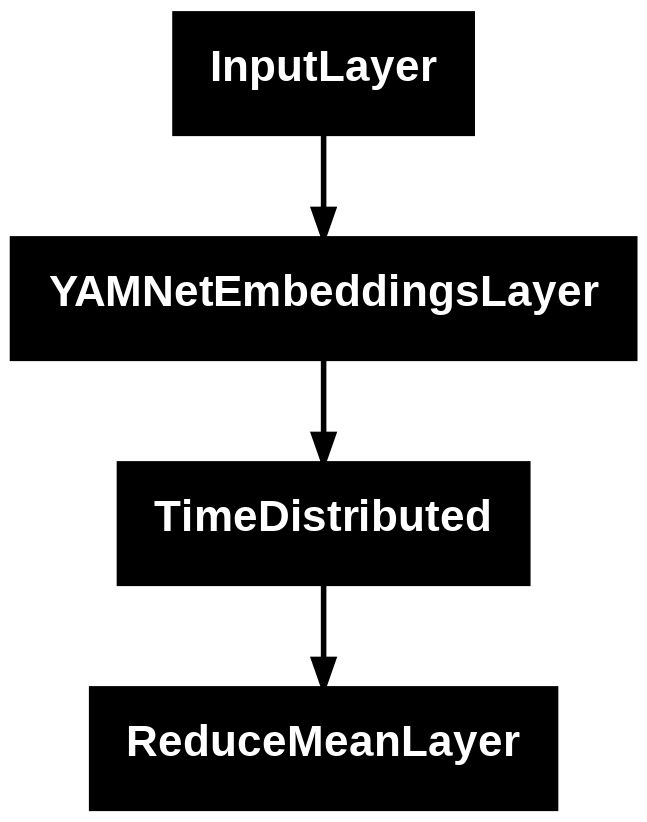

In [ ]:
tf.keras.utils.plot_model(serving_model)

In [ ]:
reloaded_model = tf.keras.models.load_model(saved_model_path, custom_objects={'YAMNetEmbeddingsLayer': YAMNetEmbeddingsLayer, 'ReduceMeanLayer': ReduceMeanLayer})

drive/MyDrive/sounds/gun/001.mp3
Waveform values: [-4.3655746e-11  1.4551915e-10 -5.7298166e-11 ... -2.0866530e-05
 -2.5588250e-05 -2.1038250e-05]


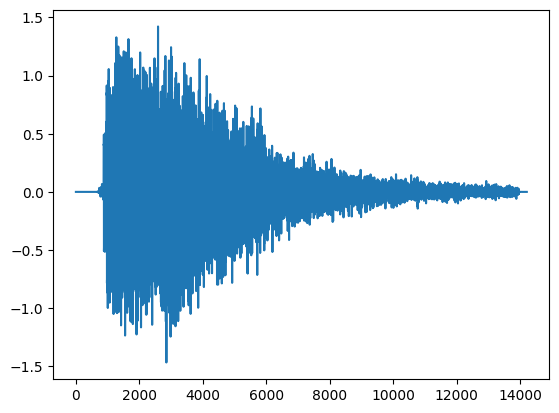

In [ ]:
filename = 'drive/MyDrive/sounds/gun/001.mp3'

print(filename)
waveform = load_wav_16k_mono(filename)
print(f'Waveform values: {waveform}')
_ = plt.plot(waveform)

display.Audio(waveform, rate=16000)

In [ ]:
scores, embeddings, spectrogram = yamnet_model(waveform)
class_scores = tf.reduce_mean(scores, axis=0)
top_class = tf.math.argmax(class_scores)
inferred_class = class_names[top_class]
top_score = class_scores[top_class]
print(f'[YAMNet] The main sound is: {inferred_class} ({top_score})')

# Add a batch dimension to the waveform
reloaded_results = reloaded_model(tf.expand_dims(waveform, axis=0))

your_top_class = tf.math.argmax(reloaded_results, axis=-1)

# Safely extract the single scalar value and convert to Python int
your_inferred_class = classes[int(your_top_class[0])]

class_probabilities = tf.nn.softmax(reloaded_results, axis=-1)

# Correctly extract the scalar probability for the top class
your_top_score = class_probabilities[0, int(your_top_class[0])]
print(f'[Your model] The main sound is: {your_inferred_class} ({your_top_score})')

[YAMNet] The main sound is: Explosion (0.2709549367427826)
[Your model] The main sound is: gun_shot (0.9996343851089478)
